In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from scipy.stats import spearmanr

print('All imports successful')

All imports successful


In [2]:
from pathlib import Path

BASE = Path('.')

TRAIN_FILE      = str(BASE / 'train.csv')
VAL_FILE        = str(BASE / 'val.csv')
TEST_FILE       = str(BASE / 'test.csv')
SAMPLE_SUB_FILE = str(BASE / 'SampleSubmission.csv')
SUBMISSION_FILE = str(BASE / 'submission.csv')

ID_COL      = 'ID'
TARGET_COLS = [
    'no_water_access', 'no_sanitation_access', 'no_refuse_access',
    'no_energy_access', 'no_education_access',
]

RANDOM_STATE = 42
print('Config loaded')

Config loaded


In [3]:
train      = pd.read_csv(TRAIN_FILE)
val        = pd.read_csv(VAL_FILE)
test       = pd.read_csv(TEST_FILE)
sample_sub = pd.read_csv(SAMPLE_SUB_FILE)

print(f'Train : {train.shape}')
print(f'Val   : {val.shape}')
print(f'Test  : {test.shape}')

Train : (8353, 31)
Val   : (1080, 31)
Test  : (4060, 26)


In [4]:
def engineer_features(df):
    df = df.copy()

    # ── Ordinal bands → integers ──────────────────────────────────────────────
    df['asset_index']      = df['asset_index'].map(
        {'0-2': 0, '3-4': 1, '5-6': 2, '7-8': 3, '9+': 4})
    df['debt_count']       = df['debt_count'].map(
        {'0': 0, '1': 1, '2': 2, '3+': 3})
    df['income_src_count'] = df['income_src_count'].map(
        {'0': 0, '1': 1, '2+': 2})
    df['hazard_count']     = df['hazard_count'].map(
        {'0': 0, '1': 1, '2': 2, '3+': 3})
    df['amenity_access']   = df['amenity_access'].map(
        {'0-2': 0, '3-4': 1, '5-6': 2, '7+': 3})
    df['chronic_count']    = df['chronic_count'].map(
        {'0': 0, '1': 1, '2+': 2})
    df['hh_size_band']     = df['hh_size_band'].map(
        {'1': 1, '2': 2, '3-4': 3, '5-6': 5, '7+': 7})
    df['rooms_band']       = df['rooms_band'].map(
        {'1-2': 1, '3-4': 3, '5+': 5})
    df['children_band']    = df['children_band'].map(
        {'0': 0, '1': 1, '2': 2, '3+': 3})
    df['age_band']         = df['age_band'].map(
        {'<25': 0, '25-34': 1, '35-44': 2, '45-54': 3,
         '55-64': 4, '65+': 5, '__SUPPRESSED__': np.nan})
    df['tenure']           = df['tenure'].map(
        {'Owned': 0, 'Renting': 1,
         'Allowed to stay rent free by owner': 2,
         'Squatting or living rent-free in an informal dwelling youve built, or in a vacant building or on vacant land': 3})
    df['transport_mode']   = df['transport_mode'].map(
        {'Car as driver': 0, 'Car as passenger': 1,
         'Minibus Taxi': 2, 'Walk': 3})
    df['health_status']    = df['health_status'].map(
        {'Excellent': 0, 'Good': 1, 'Poor': 2})
    df['marital']          = df['marital'].map(
        {'Married/common law marriage': 0,
         'In a relationship but not married': 1,
         'Single': 2, 'Divorced': 3, 'Widowed': 4})

    # ── Binary columns → 0/1 ─────────────────────────────────────────────────
    for col in ['internet', 'employed', 'social_grant', 'medical_aid', 'crime_victim']:
        df[col] = (df[col] == 'Yes').astype(int)

    df['food_insecure']    = (df['food_insecurity'] == 'insecure').astype(int)
    df['is_informal']      = (df['dwelling_type'] == 'Informal').astype(int)
    df['is_female']        = (df['sex'] == 'Female').astype(int)
    df['is_head']          = (df['head_household'] == 'Respondent').astype(int)
    df['is_black_african'] = (df['pop_group'] == 'Black African').astype(int)

    # Drop original string columns now replaced
    df = df.drop(columns=['dwelling_type', 'food_insecurity', 'sex',
                           'head_household', 'pop_group'])

    # ── Composite scores ──────────────────────────────────────────────────────
    hh = df['hh_size_band'] + 1

    df['informal_score']    = (
        df['is_informal'] +
        (df['tenure'] >= 2).astype(int)
    )
    df['ses_vulnerability'] = (
        (df['employed'] == 0).astype(int) +
        (df['medical_aid'] == 0).astype(int) +
        (df['internet'] == 0).astype(int) +
        df['social_grant'] +
        (df['asset_index'] <= 1).astype(int) +
        df['food_insecure'] +
        (df['income_src_count'] == 0).astype(int)
    )
    df['crowding_proxy']   = df['hh_size_band'] / (df['rooms_band'] + 1)
    df['dependents_total'] = df['children_band'] + df['elderly_band']
    df['isolation_score']  = (
        (df['internet'] == 0).astype(int) +
        (df['transport_mode'] >= 2).astype(int) +
        (df['amenity_access'] <= 1).astype(int) +
        (df['medical_aid'] == 0).astype(int)
    )
    df['health_burden']    = (
        df['chronic_count'] +
        df['hazard_count'] +
        df['health_status']
    )

    # ── Per capita features ───────────────────────────────────────────────────
    df['assets_per_person'] = df['asset_index'] / hh
    df['rooms_per_person']  = df['rooms_band'] / hh
    df['debt_count_per_person'] = df['debt_count'] / hh

    # ── Interaction terms ─────────────────────────────────────────────────────
    df['informal_x_ses']   = df['informal_score'] * df['ses_vulnerability']
    df['asset_x_formal']   = df['asset_index'] * (1 - df['is_informal'])
    df['asset_x_informal'] = df['asset_index'] * df['is_informal']
    df['walk_x_informal']  = (df['transport_mode'] == 3).astype(int) * df['is_informal']
    df['crowded_informal'] = df['crowding_proxy'] * df['is_informal']
    df['ses_x_isolation']  = df['ses_vulnerability'] * df['isolation_score']
    df['female_informal']  = df['is_female'] * df['is_informal']

    # ── Team features ─────────────────────────────────────────────────────────
    df['triple_zero'] = (
        (df['income_src_count'] == 0) &
        (df['asset_index'] == 0) &
        (df['amenity_access'] == 0)
    ).astype(int)

    df['no_safety_net'] = (
        (df['is_informal'] == 1) &
        (df['employed'] == 0) &
        (df['social_grant'] == 0)
    ).astype(int)

    df['is_transport_vulnerable'] = (df['transport_mode'] >= 2).astype(int)

    df['total_vulnerable_members'] = (
        df['children_band'] +
        df['chronic_count'] +
        df['elderly_band']
    )

    df['hh_size_mid'] = df['hh_size_band'].map(
        {1: 1, 2: 2, 3: 3.5, 5: 5.5, 7: 9.0})
    df['rooms_mid']   = df['rooms_band'].map(
        {1: 1.5, 3: 3.5, 5: 6.0})
    df['crowding_mid'] = df['hh_size_mid'] / (df['rooms_mid'] + 1)

    return df

print('Feature engineering function defined')

Feature engineering function defined


In [5]:
# Reload raw data to ensure clean state
train = pd.read_csv(TRAIN_FILE)
val   = pd.read_csv(VAL_FILE)
test  = pd.read_csv(TEST_FILE)

features_to_drop = [
    'crime_victim',
    'is_white',
    'debt_per_person',
    'dependency_burden',
    'income_sources_per_person',
]

X_train = engineer_features(train.drop(columns=TARGET_COLS + [ID_COL]))
X_val   = engineer_features(val.drop(columns=TARGET_COLS + [ID_COL]))
X_test  = engineer_features(test.drop(columns=[ID_COL]))

y_train = train[TARGET_COLS].values.astype(int)
y_val   = val[TARGET_COLS].values.astype(int)

X_train = X_train.drop(columns=features_to_drop, errors='ignore')
X_val   = X_val.drop(columns=features_to_drop, errors='ignore')
X_test  = X_test.drop(columns=features_to_drop, errors='ignore')

print(f'X_train : {X_train.shape}')
print(f'X_val   : {X_val.shape}')
print(f'X_test  : {X_test.shape}')
print(f'\nNull counts:')
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])
print(f'\nFeatures: {list(X_train.columns)}')

X_train : (8353, 47)
X_val   : (1080, 47)
X_test  : (4060, 47)

Null counts:
age_band    23
dtype: int64

Features: ['age_band', 'marital', 'hh_size_band', 'children_band', 'elderly_band', 'rooms_band', 'tenure', 'asset_index', 'debt_count', 'internet', 'employed', 'income_src_count', 'social_grant', 'hazard_count', 'amenity_access', 'transport_mode', 'chronic_count', 'medical_aid', 'health_status', 'food_insecure', 'is_informal', 'is_female', 'is_head', 'is_black_african', 'informal_score', 'ses_vulnerability', 'crowding_proxy', 'dependents_total', 'isolation_score', 'health_burden', 'assets_per_person', 'rooms_per_person', 'debt_count_per_person', 'informal_x_ses', 'asset_x_formal', 'asset_x_informal', 'walk_x_informal', 'crowded_informal', 'ses_x_isolation', 'female_informal', 'triple_zero', 'no_safety_net', 'is_transport_vulnerable', 'total_vulnerable_members', 'hh_size_mid', 'rooms_mid', 'crowding_mid']


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import numpy as np

# Combine train + val
X_full = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_full = np.vstack([y_train, y_val])

# Stratify on number of services missing
strat_key = y_full.sum(axis=1)

N_FOLDS  = 5
skf      = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

oof_probs  = np.zeros_like(y_full, dtype=float)
test_probs = np.zeros((X_test.shape[0], len(TARGET_COLS)), dtype=float)
fold_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_full, strat_key)):
    print(f'\n=== Fold {fold+1}/{N_FOLDS} ===')
    
    Xf_train, Xf_val = X_full.iloc[train_idx], X_full.iloc[val_idx]
    yf_train, yf_val = y_full[train_idx],       y_full[val_idx]
    
    fold_test_probs = np.zeros((X_test.shape[0], len(TARGET_COLS)), dtype=float)
    
    model = MultiOutputClassifier(
        RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=2,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
    
    model.fit(Xf_train, yf_train)
    
    # OOF predictions
    oof_preds_proba = np.column_stack([
        p[:, 1] for p in model.predict_proba(Xf_val)
    ])
    oof_probs[val_idx] = oof_preds_proba
    
    # Test predictions — average across folds
    fold_test_probs = np.column_stack([
        p[:, 1] for p in model.predict_proba(X_test)
    ])
    test_probs += fold_test_probs / N_FOLDS
    
    # Fold score at 0.5
    fold_preds = (oof_preds_proba >= 0.5).astype(int)
    fold_f1    = f1_score(yf_val, fold_preds, average='macro', zero_division=0)
    fold_scores.append(fold_f1)
    print(f'  Macro-F1 @ 0.5: {fold_f1:.4f}')

print(f'\nMean CV Macro-F1 @ 0.5: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}')


=== Fold 1/5 ===
  Macro-F1 @ 0.5: 0.3491

=== Fold 2/5 ===
  Macro-F1 @ 0.5: 0.3455

=== Fold 3/5 ===
  Macro-F1 @ 0.5: 0.3353

=== Fold 4/5 ===
  Macro-F1 @ 0.5: 0.3346

=== Fold 5/5 ===
  Macro-F1 @ 0.5: 0.3383

Mean CV Macro-F1 @ 0.5: 0.3406 ± 0.0057


In [11]:
best_thresholds = {}
tuned_f1s       = {}

print('Per-label OOF threshold tuning:\n')
print(f'  {"label":<25} {"thr":>5}  {"F1@0.5":>7}  {"F1@thr":>7}  {"delta":>7}')

for i, target in enumerate(TARGET_COLS):
    base_f1 = f1_score(
        y_full[:, i],
        (oof_probs[:, i] >= 0.5).astype(int),
        zero_division=0
    )
    best_f1, best_thr = 0, 0.5
    for thr in np.arange(0.05, 0.95, 0.01):
        preds = (oof_probs[:, i] >= thr).astype(int)
        f1    = f1_score(y_full[:, i], preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    
    best_thresholds[target] = round(best_thr, 2)
    tuned_f1s[target]       = best_f1
    print(f'  {target:<25} {best_thr:>5.2f}  {base_f1:>7.4f}  {best_f1:>7.4f}  {best_f1-base_f1:>+7.4f}')

oof_macro = np.mean(list(tuned_f1s.values()))
print(f'\nOOF Tuned Macro-F1 : {oof_macro:.4f}')
print(f'Baseline           : 0.4169')
print(f'\nBest thresholds: {best_thresholds}')

Per-label OOF threshold tuning:

  label                       thr   F1@0.5   F1@thr    delta
  no_water_access            0.43   0.5276   0.5445  +0.0168
  no_sanitation_access       0.43   0.2524   0.2673  +0.0149
  no_refuse_access           0.36   0.4076   0.4175  +0.0099
  no_energy_access           0.60   0.1890   0.1980  +0.0089
  no_education_access        0.50   0.3261   0.3261  +0.0000

OOF Tuned Macro-F1 : 0.3507
Baseline           : 0.4169

Best thresholds: {'no_water_access': np.float64(0.43), 'no_sanitation_access': np.float64(0.43), 'no_refuse_access': np.float64(0.36), 'no_energy_access': np.float64(0.6), 'no_education_access': np.float64(0.5)}


In [12]:
submission = sample_sub[[ID_COL]].copy()

for i, target in enumerate(TARGET_COLS):
    submission[target] = (
        test_probs[:, i] >= best_thresholds[target]
    ).astype(int)

assert list(submission.columns) == [ID_COL] + TARGET_COLS
assert len(submission) == len(sample_sub)
assert submission.isna().sum().sum() == 0
for col in TARGET_COLS:
    assert submission[col].isin([0, 1]).all()

print('All sanity checks passed.')
print(f'\nPredicted positives per label:')
print((submission[TARGET_COLS].mean() * 100).apply(lambda x: f'{x:.1f}%'))
print(f'\nThresholds used: {best_thresholds}')

submission.to_csv(SUBMISSION_FILE, index=False)
print(f'\nSubmission saved to: {SUBMISSION_FILE}')

All sanity checks passed.

Predicted positives per label:
no_water_access         45.8%
no_sanitation_access    21.2%
no_refuse_access        52.0%
no_energy_access         2.0%
no_education_access     11.3%
dtype: object

Thresholds used: {'no_water_access': np.float64(0.43), 'no_sanitation_access': np.float64(0.43), 'no_refuse_access': np.float64(0.36), 'no_energy_access': np.float64(0.6), 'no_education_access': np.float64(0.5)}

Submission saved to: submission.csv


In [6]:
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

oof_probs_lgb  = np.zeros_like(y_full, dtype=float)
test_probs_lgb = np.zeros((X_test.shape[0], len(TARGET_COLS)), dtype=float)
fold_scores_lgb = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_full, strat_key)):
    print(f'\n=== Fold {fold+1}/{N_FOLDS} ===')
    
    Xf_train, Xf_val = X_full.iloc[train_idx], X_full.iloc[val_idx]
    yf_train, yf_val = y_full[train_idx],       y_full[val_idx]
    
    fold_test_probs = np.zeros((X_test.shape[0], len(TARGET_COLS)), dtype=float)
    
    for i, target in enumerate(TARGET_COLS):
        model = LGBMClassifier(
            n_estimators=1000,
            learning_rate=0.05,
            num_leaves=31,
            min_child_samples=20,
            class_weight='balanced',
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1
        )
        
        model.fit(
            Xf_train, yf_train[:, i],
            eval_set=[(Xf_val, yf_val[:, i])],
            callbacks=[
                early_stopping(100, verbose=False),
                log_evaluation(500)
            ]
        )
        
        oof_probs_lgb[val_idx, i] = model.predict_proba(Xf_val)[:, 1]
        fold_test_probs[:, i]     = model.predict_proba(X_test)[:, 1]
    
    fold_preds = (oof_probs_lgb[val_idx] >= 0.5).astype(int)
    fold_f1    = f1_score(yf_val, fold_preds, average='macro', zero_division=0)
    fold_scores_lgb.append(fold_f1)
    print(f'  Macro-F1 @ 0.5: {fold_f1:.4f}')
    
    test_probs_lgb += fold_test_probs / N_FOLDS

print(f'\nLGB Mean CV Macro-F1 @ 0.5: {np.mean(fold_scores_lgb):.4f} ± {np.std(fold_scores_lgb):.4f}')

# Threshold tuning
best_thr_lgb = {}
tuned_f1_lgb = {}

print('\nPer-label OOF threshold tuning:\n')
print(f'  {"label":<25} {"thr":>5}  {"F1@0.5":>7}  {"F1@thr":>7}')

for i, target in enumerate(TARGET_COLS):
    base_f1 = f1_score(y_full[:, i],
                       (oof_probs_lgb[:, i] >= 0.5).astype(int),
                       zero_division=0)
    best_f1, best_thr = 0, 0.5
    for thr in np.arange(0.05, 0.95, 0.01):
        preds = (oof_probs_lgb[:, i] >= thr).astype(int)
        f1    = f1_score(y_full[:, i], preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    best_thr_lgb[target] = round(best_thr, 2)
    tuned_f1_lgb[target] = best_f1
    print(f'  {target:<25} {best_thr:>5.2f}  {base_f1:>7.4f}  {best_f1:>7.4f}')

lgb_oof_macro = np.mean(list(tuned_f1_lgb.values()))
print(f'\nLGB OOF Tuned Macro-F1 : {lgb_oof_macro:.4f}')

RF Macro-F1 @ 0.5 : 0.3994
Baseline was      : 0.4169

Per-label F1:
  no_water_access           0.5164
  no_sanitation_access      0.3746
  no_refuse_access          0.4201
  no_energy_access          0.3393
  no_education_access       0.3466


In [13]:
from xgboost import XGBClassifier

oof_probs_xgb  = np.zeros_like(y_full, dtype=float)
test_probs_xgb = np.zeros((X_test.shape[0], len(TARGET_COLS)), dtype=float)
fold_scores_xgb = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_full, strat_key)):
    print(f'\n=== Fold {fold+1}/{N_FOLDS} ===')
    
    Xf_train, Xf_val = X_full.iloc[train_idx], X_full.iloc[val_idx]
    yf_train, yf_val = y_full[train_idx],       y_full[val_idx]
    
    fold_test_probs = np.zeros((X_test.shape[0], len(TARGET_COLS)), dtype=float)
    
    for i, target in enumerate(TARGET_COLS):
        neg = (yf_train[:, i] == 0).sum()
        pos = (yf_train[:, i] == 1).sum()
        scale = neg / pos
        
        model = XGBClassifier(
            n_estimators=1000,
            learning_rate=0.05,
            max_depth=6,
            scale_pos_weight=scale,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,
            eval_metric='logloss',
            early_stopping_rounds=100
        )
        
        model.fit(
            Xf_train, yf_train[:, i],
            eval_set=[(Xf_val, yf_val[:, i])],
            verbose=False
        )
        
        oof_probs_xgb[val_idx, i] = model.predict_proba(Xf_val)[:, 1]
        fold_test_probs[:, i]     = model.predict_proba(X_test)[:, 1]
    
    fold_preds = (oof_probs_xgb[val_idx] >= 0.5).astype(int)
    fold_f1    = f1_score(yf_val, fold_preds, average='macro', zero_division=0)
    fold_scores_xgb.append(fold_f1)
    print(f'  Macro-F1 @ 0.5: {fold_f1:.4f}')
    
    test_probs_xgb += fold_test_probs / N_FOLDS

print(f'\nXGB Mean CV Macro-F1 @ 0.5: {np.mean(fold_scores_xgb):.4f} ± {np.std(fold_scores_xgb):.4f}')

# Threshold tuning
best_thr_xgb = {}
tuned_f1_xgb = {}

print('\nPer-label OOF threshold tuning:\n')
print(f'  {"label":<25} {"thr":>5}  {"F1@0.5":>7}  {"F1@thr":>7}')

for i, target in enumerate(TARGET_COLS):
    base_f1 = f1_score(y_full[:, i],
                       (oof_probs_xgb[:, i] >= 0.5).astype(int),
                       zero_division=0)
    best_f1, best_thr = 0, 0.5
    for thr in np.arange(0.05, 0.95, 0.01):
        preds = (oof_probs_xgb[:, i] >= thr).astype(int)
        f1    = f1_score(y_full[:, i], preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    best_thr_xgb[target] = round(best_thr, 2)
    tuned_f1_xgb[target] = best_f1
    print(f'  {target:<25} {best_thr:>5.2f}  {base_f1:>7.4f}  {best_f1:>7.4f}')

xgb_oof_macro = np.mean(list(tuned_f1_xgb.values()))
print(f'\nXGB OOF Tuned Macro-F1 : {xgb_oof_macro:.4f}')


=== Fold 1/5 ===
  Macro-F1 @ 0.5: 0.3640

=== Fold 2/5 ===
  Macro-F1 @ 0.5: 0.3560

=== Fold 3/5 ===
  Macro-F1 @ 0.5: 0.3586

=== Fold 4/5 ===
  Macro-F1 @ 0.5: 0.3566

=== Fold 5/5 ===
  Macro-F1 @ 0.5: 0.3643

XGB Mean CV Macro-F1 @ 0.5: 0.3599 ± 0.0036

Per-label OOF threshold tuning:

  label                       thr   F1@0.5   F1@thr
  no_water_access            0.48   0.5603   0.5630
  no_sanitation_access       0.67   0.2894   0.3093
  no_refuse_access           0.50   0.4467   0.4467
  no_energy_access           0.76   0.1891   0.2372
  no_education_access        0.65   0.3147   0.3533

XGB OOF Tuned Macro-F1 : 0.3819


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier

oof_probs_rf  = np.zeros_like(y_full, dtype=float)
test_probs_rf = np.zeros((X_test.shape[0], len(TARGET_COLS)), dtype=float)
fold_scores_rf = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_full, strat_key)):
    print(f'\n=== Fold {fold+1}/{N_FOLDS} ===')
    
    Xf_train, Xf_val = X_full.iloc[train_idx], X_full.iloc[val_idx]
    yf_train, yf_val = y_full[train_idx],       y_full[val_idx]
    
    fold_test_probs = np.zeros((X_test.shape[0], len(TARGET_COLS)), dtype=float)
    
    model = MultiOutputClassifier(
        RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=2,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
    
    model.fit(Xf_train, yf_train)
    
    oof_preds_proba = np.column_stack([
        p[:, 1] for p in model.predict_proba(Xf_val)
    ])
    oof_probs_rf[val_idx] = oof_preds_proba
    
    fold_test_probs = np.column_stack([
        p[:, 1] for p in model.predict_proba(X_test)
    ])
    test_probs_rf += fold_test_probs / N_FOLDS
    
    fold_preds = (oof_preds_proba >= 0.5).astype(int)
    fold_f1    = f1_score(yf_val, fold_preds, average='macro', zero_division=0)
    fold_scores_rf.append(fold_f1)
    print(f'  Macro-F1 @ 0.5: {fold_f1:.4f}')

print(f'\nRF Mean CV Macro-F1 @ 0.5: {np.mean(fold_scores_rf):.4f} ± {np.std(fold_scores_rf):.4f}')

# Threshold tuning
best_thr_rf = {}
tuned_f1_rf = {}

print('\nPer-label OOF threshold tuning:\n')
print(f'  {"label":<25} {"thr":>5}  {"F1@0.5":>7}  {"F1@thr":>7}')

for i, target in enumerate(TARGET_COLS):
    base_f1 = f1_score(y_full[:, i],
                       (oof_probs_rf[:, i] >= 0.5).astype(int),
                       zero_division=0)
    best_f1, best_thr = 0, 0.5
    for thr in np.arange(0.05, 0.95, 0.01):
        preds = (oof_probs_rf[:, i] >= thr).astype(int)
        f1    = f1_score(y_full[:, i], preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    best_thr_rf[target] = round(best_thr, 2)
    tuned_f1_rf[target] = best_f1
    print(f'  {target:<25} {best_thr:>5.2f}  {base_f1:>7.4f}  {best_f1:>7.4f}')

rf_oof_macro = np.mean(list(tuned_f1_rf.values()))
print(f'\nRF OOF Tuned Macro-F1 : {rf_oof_macro:.4f}')


=== Fold 1/5 ===
  Macro-F1 @ 0.5: 0.3491

=== Fold 2/5 ===
  Macro-F1 @ 0.5: 0.3455

=== Fold 3/5 ===
  Macro-F1 @ 0.5: 0.3353

=== Fold 4/5 ===
  Macro-F1 @ 0.5: 0.3346

=== Fold 5/5 ===
  Macro-F1 @ 0.5: 0.3383

RF Mean CV Macro-F1 @ 0.5: 0.3406 ± 0.0057

Per-label OOF threshold tuning:

  label                       thr   F1@0.5   F1@thr
  no_water_access            0.43   0.5276   0.5445
  no_sanitation_access       0.43   0.2524   0.2673
  no_refuse_access           0.36   0.4076   0.4175
  no_energy_access           0.60   0.1890   0.1980
  no_education_access        0.50   0.3261   0.3261

RF OOF Tuned Macro-F1 : 0.3507


In [15]:
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

oof_probs_lgb  = np.zeros_like(y_full, dtype=float)
test_probs_lgb = np.zeros((X_test.shape[0], len(TARGET_COLS)), dtype=float)
fold_scores_lgb = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_full, strat_key)):
    print(f'\n=== Fold {fold+1}/{N_FOLDS} ===')
    
    Xf_train, Xf_val = X_full.iloc[train_idx], X_full.iloc[val_idx]
    yf_train, yf_val = y_full[train_idx],       y_full[val_idx]
    
    fold_test_probs = np.zeros((X_test.shape[0], len(TARGET_COLS)), dtype=float)
    
    for i, target in enumerate(TARGET_COLS):
        model = LGBMClassifier(
            n_estimators=1000,
            learning_rate=0.05,
            num_leaves=31,
            min_child_samples=20,
            class_weight='balanced',
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1
        )
        
        model.fit(
            Xf_train, yf_train[:, i],
            eval_set=[(Xf_val, yf_val[:, i])],
            callbacks=[
                early_stopping(100, verbose=False),
                log_evaluation(500)
            ]
        )
        
        oof_probs_lgb[val_idx, i] = model.predict_proba(Xf_val)[:, 1]
        fold_test_probs[:, i]     = model.predict_proba(X_test)[:, 1]
    
    fold_preds = (oof_probs_lgb[val_idx] >= 0.5).astype(int)
    fold_f1    = f1_score(yf_val, fold_preds, average='macro', zero_division=0)
    fold_scores_lgb.append(fold_f1)
    print(f'  Macro-F1 @ 0.5: {fold_f1:.4f}')
    
    test_probs_lgb += fold_test_probs / N_FOLDS

print(f'\nLGB Mean CV Macro-F1 @ 0.5: {np.mean(fold_scores_lgb):.4f} ± {np.std(fold_scores_lgb):.4f}')

# Threshold tuning
best_thr_lgb = {}
tuned_f1_lgb = {}

print('\nPer-label OOF threshold tuning:\n')
print(f'  {"label":<25} {"thr":>5}  {"F1@0.5":>7}  {"F1@thr":>7}')

for i, target in enumerate(TARGET_COLS):
    base_f1 = f1_score(y_full[:, i],
                       (oof_probs_lgb[:, i] >= 0.5).astype(int),
                       zero_division=0)
    best_f1, best_thr = 0, 0.5
    for thr in np.arange(0.05, 0.95, 0.01):
        preds = (oof_probs_lgb[:, i] >= thr).astype(int)
        f1    = f1_score(y_full[:, i], preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    best_thr_lgb[target] = round(best_thr, 2)
    tuned_f1_lgb[target] = best_f1
    print(f'  {target:<25} {best_thr:>5.2f}  {base_f1:>7.4f}  {best_f1:>7.4f}')

lgb_oof_macro = np.mean(list(tuned_f1_lgb.values()))
print(f'\nLGB OOF Tuned Macro-F1 : {lgb_oof_macro:.4f}')


=== Fold 1/5 ===
  Macro-F1 @ 0.5: 0.3614

=== Fold 2/5 ===
  Macro-F1 @ 0.5: 0.3533

=== Fold 3/5 ===
  Macro-F1 @ 0.5: 0.3537

=== Fold 4/5 ===
  Macro-F1 @ 0.5: 0.3534

=== Fold 5/5 ===
  Macro-F1 @ 0.5: 0.3573

LGB Mean CV Macro-F1 @ 0.5: 0.3558 ± 0.0032

Per-label OOF threshold tuning:

  label                       thr   F1@0.5   F1@thr
  no_water_access            0.48   0.5598   0.5658
  no_sanitation_access       0.73   0.2816   0.3109
  no_refuse_access           0.53   0.4483   0.4532
  no_energy_access           0.78   0.1838   0.2415
  no_education_access        0.66   0.3062   0.3499

LGB OOF Tuned Macro-F1 : 0.3842


In [16]:
submission = sample_sub[[ID_COL]].copy()

for i, target in enumerate(TARGET_COLS):
    submission[target] = (
        test_probs_lgb[:, i] >= best_thr_lgb[target]
    ).astype(int)

assert list(submission.columns) == [ID_COL] + TARGET_COLS
assert len(submission) == len(sample_sub)
assert submission.isna().sum().sum() == 0
for col in TARGET_COLS:
    assert submission[col].isin([0, 1]).all()

print('All sanity checks passed.')
print(f'\nPredicted positives per label:')
print((submission[TARGET_COLS].mean() * 100).apply(lambda x: f'{x:.1f}%'))
print(f'\nThresholds used: {best_thr_lgb}')

submission.to_csv(SUBMISSION_FILE, index=False)
print(f'\nSubmission saved.')

All sanity checks passed.

Predicted positives per label:
no_water_access         52.5%
no_sanitation_access     7.1%
no_refuse_access        31.8%
no_energy_access         2.7%
no_education_access     12.6%
dtype: object

Thresholds used: {'no_water_access': np.float64(0.48), 'no_sanitation_access': np.float64(0.73), 'no_refuse_access': np.float64(0.53), 'no_energy_access': np.float64(0.78), 'no_education_access': np.float64(0.66)}

Submission saved.


In [17]:
test_probs_ensemble = (test_probs_lgb + test_probs_xgb) / 2

In [18]:
# ── Ensemble LGB + XGB ────────────────────────────────────────────────────────
test_probs_ensemble = (test_probs_lgb + test_probs_xgb) / 2
oof_probs_ensemble  = (oof_probs_lgb  + oof_probs_xgb)  / 2

# Tune thresholds on ensemble OOF
best_thr_ens = {}
tuned_f1_ens = {}

print('Ensemble OOF threshold tuning:\n')
print(f'  {"label":<25} {"thr":>5}  {"F1@0.5":>7}  {"F1@thr":>7}')

for i, target in enumerate(TARGET_COLS):
    base_f1 = f1_score(y_full[:, i],
                       (oof_probs_ensemble[:, i] >= 0.5).astype(int),
                       zero_division=0)
    best_f1, best_thr = 0, 0.5
    for thr in np.arange(0.05, 0.95, 0.01):
        preds = (oof_probs_ensemble[:, i] >= thr).astype(int)
        f1    = f1_score(y_full[:, i], preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    best_thr_ens[target] = round(best_thr, 2)
    tuned_f1_ens[target] = best_f1
    print(f'  {target:<25} {best_thr:>5.2f}  {base_f1:>7.4f}  {best_f1:>7.4f}')

ens_oof_macro = np.mean(list(tuned_f1_ens.values()))
print(f'\nEnsemble OOF Tuned Macro-F1 : {ens_oof_macro:.4f}')
print(f'LGB alone                   : {lgb_oof_macro:.4f}')
print(f'XGB alone                   : {xgb_oof_macro:.4f}')

# Generate submission only if ensemble beats LGB alone
if ens_oof_macro > lgb_oof_macro:
    print('\nEnsemble wins — generating submission')
    submission = sample_sub[[ID_COL]].copy()
    for i, target in enumerate(TARGET_COLS):
        submission[target] = (
            test_probs_ensemble[:, i] >= best_thr_ens[target]
        ).astype(int)
    assert list(submission.columns) == [ID_COL] + TARGET_COLS
    assert len(submission) == len(sample_sub)
    assert submission.isna().sum().sum() == 0
    print(f'\nPredicted positives per label:')
    print((submission[TARGET_COLS].mean() * 100).apply(lambda x: f'{x:.1f}%'))
    submission.to_csv(SUBMISSION_FILE, index=False)
    print(f'\nSubmission saved.')
else:
    print('\nLGB alone is still better — do not submit ensemble yet')

Ensemble OOF threshold tuning:

  label                       thr   F1@0.5   F1@thr
  no_water_access            0.47   0.5621   0.5647
  no_sanitation_access       0.67   0.2847   0.3158
  no_refuse_access           0.50   0.4486   0.4486
  no_energy_access           0.75   0.1857   0.2421
  no_education_access        0.64   0.3109   0.3500

Ensemble OOF Tuned Macro-F1 : 0.3842
LGB alone                   : 0.3842
XGB alone                   : 0.3819

LGB alone is still better — do not submit ensemble yet


Running model comparison...

Running RandomForest...
  RandomForest              OOF Tuned Macro-F1: 0.3507

Running ExtraTrees...
  ExtraTrees                OOF Tuned Macro-F1: 0.3496

Running HistGradientBoosting...
  HistGradientBoosting      OOF Tuned Macro-F1: 0.3565

Running LogisticRegression...
  LogisticRegression        OOF Tuned Macro-F1: 0.3987

Running SVM...
  SVM                       OOF Tuned Macro-F1: 0.3793

Running LightGBM...
  LightGBM                  OOF Tuned Macro-F1: 0.3842

Running XGBoost...
  XGBoost                   OOF Tuned Macro-F1: 0.3819

Running CatBoost...
  CatBoost                  OOF Tuned Macro-F1: 0.4019

=== Final Model Comparison ===

  Model                       OOF Tuned Macro-F1
------------------------------------------------
  CatBoost                    0.4019  ████████████████████████
  LogisticRegression          0.3987  ███████████████████████
  LightGBM                    0.3842  ███████████████████████
  XGBoost               

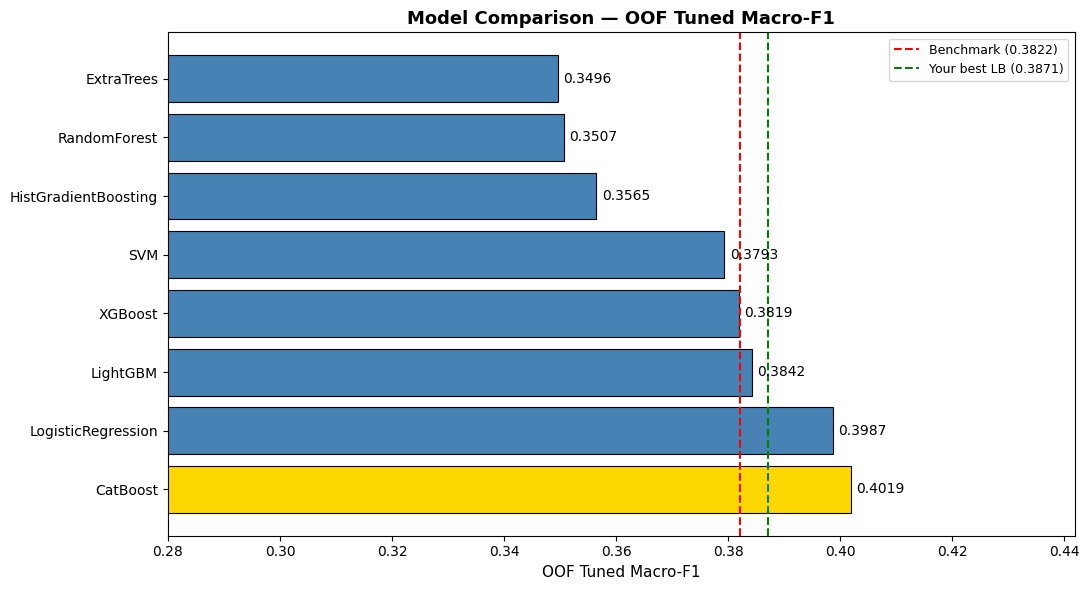


Chart saved to model_comparison.png


In [20]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import numpy as np

# ── OOF evaluation for sklearn-style models ───────────────────────────────────
def run_oof_sklearn(model_name, model):
    print(f'\nRunning {model_name}...')
    oof  = np.zeros_like(y_full, dtype=float)
    tpro = np.zeros((X_test.shape[0], len(TARGET_COLS)), dtype=float)
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_full, strat_key)):
        print(f'  Fold {fold+1}/{N_FOLDS}', end='\r')
        Xf_tr, Xf_val = X_full.iloc[train_idx], X_full.iloc[val_idx]
        yf_tr, yf_val = y_full[train_idx],       y_full[val_idx]
        
        model.fit(Xf_tr, yf_tr)
        
        oof[val_idx] = np.column_stack([
            p[:, 1] for p in model.predict_proba(Xf_val)
        ])
        tpro += np.column_stack([
            p[:, 1] for p in model.predict_proba(X_test)
        ]) / N_FOLDS
    
    # Tune thresholds on OOF
    tuned_f1s = []
    for i in range(len(TARGET_COLS)):
        best_f1 = 0
        for thr in np.arange(0.05, 0.95, 0.01):
            f1 = f1_score(
                y_full[:, i],
                (oof[:, i] >= thr).astype(int),
                zero_division=0
            )
            if f1 > best_f1:
                best_f1 = f1
        tuned_f1s.append(best_f1)
    
    macro = np.mean(tuned_f1s)
    print(f'  {model_name:<25} OOF Tuned Macro-F1: {macro:.4f}')
    return macro, oof, tpro


# ── OOF evaluation for boosting models (per-label loop) ──────────────────────
def run_oof_boosting(model_name, model_fn):
    print(f'\nRunning {model_name}...')
    oof  = np.zeros_like(y_full, dtype=float)
    tpro = np.zeros((X_test.shape[0], len(TARGET_COLS)), dtype=float)
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_full, strat_key)):
        print(f'  Fold {fold+1}/{N_FOLDS}', end='\r')
        Xf_tr, Xf_val = X_full.iloc[train_idx], X_full.iloc[val_idx]
        yf_tr, yf_val = y_full[train_idx],       y_full[val_idx]
        
        for i in range(len(TARGET_COLS)):
            neg   = (yf_tr[:, i] == 0).sum()
            pos   = (yf_tr[:, i] == 1).sum()
            model = model_fn(neg, pos)
            
            if model_name == 'LightGBM':
                model.fit(
                    Xf_tr, yf_tr[:, i],
                    eval_set=[(Xf_val, yf_val[:, i])],
                    callbacks=[
                        early_stopping(100, verbose=False),
                        log_evaluation(99999)
                    ]
                )
            elif model_name == 'CatBoost':
                model.fit(
                    Xf_tr, yf_tr[:, i],
                    eval_set=(Xf_val, yf_val[:, i]),
                    verbose=False
                )
            else:
                model.fit(
                    Xf_tr, yf_tr[:, i],
                    eval_set=[(Xf_val, yf_val[:, i])],
                    verbose=False
                )
            
            oof[val_idx, i] = model.predict_proba(Xf_val)[:, 1]
            tpro[:, i]     += model.predict_proba(X_test)[:, 1] / N_FOLDS
    
    # Tune thresholds on OOF
    tuned_f1s = []
    for i in range(len(TARGET_COLS)):
        best_f1 = 0
        for thr in np.arange(0.05, 0.95, 0.01):
            f1 = f1_score(
                y_full[:, i],
                (oof[:, i] >= thr).astype(int),
                zero_division=0
            )
            if f1 > best_f1:
                best_f1 = f1
        tuned_f1s.append(best_f1)
    
    macro = np.mean(tuned_f1s)
    print(f'  {model_name:<25} OOF Tuned Macro-F1: {macro:.4f}')
    return macro, oof, tpro


# ── Run all models ─────────────────────────────────────────────────────────────
print('=' * 50)
print('Running model comparison...')
print('=' * 50)

results = {}

# Random Forest
macro, oof, tpro = run_oof_sklearn(
    'RandomForest',
    MultiOutputClassifier(
        RandomForestClassifier(
            n_estimators=500,
            min_samples_leaf=2,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
)
results['RandomForest'] = {'macro': macro, 'oof': oof, 'test': tpro}

# Extra Trees
macro, oof, tpro = run_oof_sklearn(
    'ExtraTrees',
    MultiOutputClassifier(
        ExtraTreesClassifier(
            n_estimators=500,
            min_samples_leaf=2,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
)
results['ExtraTrees'] = {'macro': macro, 'oof': oof, 'test': tpro}

# HistGradientBoosting
macro, oof, tpro = run_oof_sklearn(
    'HistGradientBoosting',
    MultiOutputClassifier(
        HistGradientBoostingClassifier(
            max_iter=500,
            learning_rate=0.05,
            max_leaf_nodes=31,
            random_state=RANDOM_STATE
        )
    )
)
results['HistGradientBoosting'] = {'macro': macro, 'oof': oof, 'test': tpro}

# Logistic Regression
macro, oof, tpro = run_oof_sklearn(
    'LogisticRegression',
    MultiOutputClassifier(
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('lr', LogisticRegression(
                class_weight='balanced',
                max_iter=1000,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ])
    )
)
results['LogisticRegression'] = {'macro': macro, 'oof': oof, 'test': tpro}


# SVM
macro, oof, tpro = run_oof_sklearn(
    'SVM',
    MultiOutputClassifier(
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('svm', SVC(
                kernel='rbf',
                C=1.0,
                gamma='scale',
                class_weight='balanced',
                probability=True,
                random_state=RANDOM_STATE
            ))
        ])
    )
)
results['SVM'] = {'macro': macro, 'oof': oof, 'test': tpro}

# LightGBM
macro, oof, tpro = run_oof_boosting(
    'LightGBM',
    lambda neg, pos: LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=20,
        class_weight='balanced',
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    )
)
results['LightGBM'] = {'macro': macro, 'oof': oof, 'test': tpro}

# XGBoost
macro, oof, tpro = run_oof_boosting(
    'XGBoost',
    lambda neg, pos: XGBClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=neg/pos,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
        eval_metric='logloss',
        early_stopping_rounds=100
    )
)
results['XGBoost'] = {'macro': macro, 'oof': oof, 'test': tpro}

# CatBoost
macro, oof, tpro = run_oof_boosting(
    'CatBoost',
    lambda neg, pos: CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        scale_pos_weight=neg/pos,
        random_seed=RANDOM_STATE,
        verbose=False,
        early_stopping_rounds=100
    )
)
results['CatBoost'] = {'macro': macro, 'oof': oof, 'test': tpro}

# ── Print summary ──────────────────────────────────────────────────────────────
print('\n' + '=' * 50)
print('=== Final Model Comparison ===')
print('=' * 50 + '\n')
print(f'  {"Model":<25} {"OOF Tuned Macro-F1":>20}')
print('-' * 48)

sorted_results = sorted(
    results.items(),
    key=lambda x: x[1]['macro'],
    reverse=True
)
for name, res in sorted_results:
    bar = '█' * int(res['macro'] * 60)
    print(f'  {name:<25} {res["macro"]:>8.4f}  {bar}')

best_model_name = sorted_results[0][0]
best_score      = sorted_results[0][1]['macro']
print(f'\nBest model : {best_model_name}')
print(f'Best score : {best_score:.4f}')
print(f'Benchmark  : 0.3822')
print(f'Your best  : 0.3871')

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

names  = [n for n, _ in sorted_results]
scores = [r['macro'] for _, r in sorted_results]
colors = ['gold' if n == best_model_name else 'steelblue' for n in names]

bars = ax.barh(names, scores, color=colors, edgecolor='k', linewidth=0.8)

ax.axvline(
    x=0.3822, color='red',
    linestyle='--', linewidth=1.5,
    label='Benchmark (0.3822)'
)
ax.axvline(
    x=0.3871, color='green',
    linestyle='--', linewidth=1.5,
    label='Your best LB (0.3871)'
)

for bar, score in zip(bars, scores):
    ax.text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f'{score:.4f}',
        va='center', fontsize=10
    )

ax.set_xlabel('OOF Tuned Macro-F1', fontsize=11)
ax.set_title(
    'Model Comparison — OOF Tuned Macro-F1',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=9)
ax.set_xlim(0.28, max(scores) + 0.04)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nChart saved to model_comparison.png')

In [21]:
from catboost import CatBoostClassifier
import numpy as np

oof_probs_cat  = np.zeros_like(y_full, dtype=float)
test_probs_cat = np.zeros((X_test.shape[0], len(TARGET_COLS)), dtype=float)
fold_scores_cat = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_full, strat_key)):
    print(f'\n=== Fold {fold+1}/{N_FOLDS} ===')
    
    Xf_tr, Xf_val = X_full.iloc[train_idx], X_full.iloc[val_idx]
    yf_tr, yf_val = y_full[train_idx],       y_full[val_idx]
    
    fold_test_probs = np.zeros((X_test.shape[0], len(TARGET_COLS)), dtype=float)
    
    for i, target in enumerate(TARGET_COLS):
        neg = (yf_tr[:, i] == 0).sum()
        pos = (yf_tr[:, i] == 1).sum()
        
        model = CatBoostClassifier(
            iterations=1000,
            learning_rate=0.05,
            depth=6,
            scale_pos_weight=neg/pos,
            random_seed=RANDOM_STATE,
            verbose=False,
            early_stopping_rounds=100
        )
        
        model.fit(
            Xf_tr, yf_tr[:, i],
            eval_set=(Xf_val, yf_val[:, i]),
            verbose=False
        )
        
        oof_probs_cat[val_idx, i] = model.predict_proba(Xf_val)[:, 1]
        fold_test_probs[:, i]     = model.predict_proba(X_test)[:, 1]
        print(f'  {target:<25} done')
    
    fold_preds = (oof_probs_cat[val_idx] >= 0.5).astype(int)
    fold_f1    = f1_score(yf_val, fold_preds, average='macro', zero_division=0)
    fold_scores_cat.append(fold_f1)
    print(f'  Fold {fold+1} Macro-F1 @ 0.5: {fold_f1:.4f}')
    
    test_probs_cat += fold_test_probs / N_FOLDS

print(f'\nMean CV Macro-F1 @ 0.5: {np.mean(fold_scores_cat):.4f} ± {np.std(fold_scores_cat):.4f}')

# ── Tune thresholds on OOF ────────────────────────────────────────────────────
best_thr_cat = {}
tuned_f1_cat = {}

print('\nPer-label OOF threshold tuning:\n')
print(f'  {"label":<25} {"thr":>5}  {"F1@0.5":>7}  {"F1@thr":>7}')

for i, target in enumerate(TARGET_COLS):
    base_f1 = f1_score(y_full[:, i],
                       (oof_probs_cat[:, i] >= 0.5).astype(int),
                       zero_division=0)
    best_f1, best_thr = 0, 0.5
    for thr in np.arange(0.05, 0.95, 0.01):
        preds = (oof_probs_cat[:, i] >= thr).astype(int)
        f1    = f1_score(y_full[:, i], preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    best_thr_cat[target] = round(best_thr, 2)
    tuned_f1_cat[target] = best_f1
    print(f'  {target:<25} {best_thr:>5.2f}  {base_f1:>7.4f}  {best_f1:>7.4f}')

cat_oof_macro = np.mean(list(tuned_f1_cat.values()))
print(f'\nCatBoost OOF Tuned Macro-F1 : {cat_oof_macro:.4f}')
print(f'Your best LB                : 0.3871')

# ── Generate submission ───────────────────────────────────────────────────────
submission = sample_sub[[ID_COL]].copy()

for i, target in enumerate(TARGET_COLS):
    submission[target] = (
        test_probs_cat[:, i] >= best_thr_cat[target]
    ).astype(int)

assert list(submission.columns) == [ID_COL] + TARGET_COLS
assert len(submission) == len(sample_sub)
assert submission.isna().sum().sum() == 0
for col in TARGET_COLS:
    assert submission[col].isin([0, 1]).all()

print('\nAll sanity checks passed.')
print(f'\nPredicted positives per label:')
print((submission[TARGET_COLS].mean() * 100).apply(lambda x: f'{x:.1f}%'))
print(f'\nThresholds used: {best_thr_cat}')

submission.to_csv(SUBMISSION_FILE, index=False)
print(f'\nSubmission saved to: {SUBMISSION_FILE}')


=== Fold 1/5 ===
  no_water_access           done
  no_sanitation_access      done
  no_refuse_access          done
  no_energy_access          done
  no_education_access       done
  Fold 1 Macro-F1 @ 0.5: 0.3754

=== Fold 2/5 ===
  no_water_access           done
  no_sanitation_access      done
  no_refuse_access          done
  no_energy_access          done
  no_education_access       done
  Fold 2 Macro-F1 @ 0.5: 0.3666

=== Fold 3/5 ===
  no_water_access           done
  no_sanitation_access      done
  no_refuse_access          done
  no_energy_access          done
  no_education_access       done
  Fold 3 Macro-F1 @ 0.5: 0.3632

=== Fold 4/5 ===
  no_water_access           done
  no_sanitation_access      done
  no_refuse_access          done
  no_energy_access          done
  no_education_access       done
  Fold 4 Macro-F1 @ 0.5: 0.3761

=== Fold 5/5 ===
  no_water_access           done
  no_sanitation_access      done
  no_refuse_access          done
  no_energy_access     

In [23]:
# Manually adjusted thresholds to bring predicted rates closer to true rates
manual_thresholds = {
    'no_water_access':       0.58,  # reduce from 50% towards 27.5%
    'no_sanitation_access':  0.72,  # reduce from 20.4% towards 9.2%
    'no_refuse_access':      0.60,  # reduce from 38.2% towards 22.9%
    'no_energy_access':      0.74,  # already close, keep
    'no_education_access':   0.72,  # reduce from 16.7% towards 9.6%
}

submission = sample_sub[[ID_COL]].copy()
for i, target in enumerate(TARGET_COLS):
    submission[target] = (
        test_probs_cat[:, i] >= manual_thresholds[target]
    ).astype(int)

print('Predicted positives per label:')
print((submission[TARGET_COLS].mean() * 100).apply(lambda x: f'{x:.1f}%'))
print(f'\nThresholds used: {manual_thresholds}')

submission.to_csv(SUBMISSION_FILE, index=False)
print('Submission saved.')

Predicted positives per label:
no_water_access         32.3%
no_sanitation_access     5.9%
no_refuse_access        21.2%
no_energy_access         5.4%
no_education_access      9.4%
dtype: object

Thresholds used: {'no_water_access': 0.58, 'no_sanitation_access': 0.72, 'no_refuse_access': 0.6, 'no_energy_access': 0.74, 'no_education_access': 0.72}
Submission saved.


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

oof_probs_lr  = np.zeros_like(y_full, dtype=float)
test_probs_lr = np.zeros((X_test.shape[0], len(TARGET_COLS)), dtype=float)
fold_scores_lr = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_full, strat_key)):
    print(f'\n=== Fold {fold+1}/{N_FOLDS} ===')
    
    Xf_tr, Xf_val = X_full.iloc[train_idx], X_full.iloc[val_idx]
    yf_tr, yf_val = y_full[train_idx],       y_full[val_idx]
    
    model = MultiOutputClassifier(
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler',  StandardScaler()),
            ('lr', LogisticRegression(
                C=1.0,
                class_weight='balanced',
                max_iter=1000,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ])
    )
    
    model.fit(Xf_tr, yf_tr)
    
    oof_probs_lr[val_idx] = np.column_stack([
        p[:, 1] for p in model.predict_proba(Xf_val)
    ])
    test_probs_lr += np.column_stack([
        p[:, 1] for p in model.predict_proba(X_test)
    ]) / N_FOLDS
    
    fold_preds = (oof_probs_lr[val_idx] >= 0.5).astype(int)
    fold_f1    = f1_score(yf_val, fold_preds, average='macro', zero_division=0)
    fold_scores_lr.append(fold_f1)
    print(f'  Fold {fold+1} Macro-F1 @ 0.5: {fold_f1:.4f}')

print(f'\nMean CV Macro-F1 @ 0.5: {np.mean(fold_scores_lr):.4f} ± {np.std(fold_scores_lr):.4f}')

# ── Tune thresholds ───────────────────────────────────────────────────────────
best_thr_lr = {}
tuned_f1_lr = {}

print('\nPer-label OOF threshold tuning:\n')
print(f'  {"label":<25} {"thr":>5}  {"F1@0.5":>7}  {"F1@thr":>7}')

for i, target in enumerate(TARGET_COLS):
    base_f1 = f1_score(y_full[:, i],
                       (oof_probs_lr[:, i] >= 0.5).astype(int),
                       zero_division=0)
    best_f1, best_thr = 0, 0.5
    for thr in np.arange(0.05, 0.95, 0.01):
        preds = (oof_probs_lr[:, i] >= thr).astype(int)
        f1    = f1_score(y_full[:, i], preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    best_thr_lr[target] = round(best_thr, 2)
    tuned_f1_lr[target] = best_f1
    print(f'  {target:<25} {best_thr:>5.2f}  {base_f1:>7.4f}  {best_f1:>7.4f}')

lr_oof_macro = np.mean(list(tuned_f1_lr.values()))
print(f'\nLR OOF Tuned Macro-F1 : {lr_oof_macro:.4f}')

# ── Generate submission ───────────────────────────────────────────────────────
submission = sample_sub[[ID_COL]].copy()
for i, target in enumerate(TARGET_COLS):
    submission[target] = (
        test_probs_lr[:, i] >= best_thr_lr[target]
    ).astype(int)

assert list(submission.columns) == [ID_COL] + TARGET_COLS
assert len(submission) == len(sample_sub)
assert submission.isna().sum().sum() == 0

print('\nAll sanity checks passed.')
print(f'\nPredicted positives per label:')
print((submission[TARGET_COLS].mean() * 100).apply(lambda x: f'{x:.1f}%'))
print(f'\nThresholds used: {best_thr_lr}')

submission.to_csv(SUBMISSION_FILE, index=False)
print(f'\nSubmission saved.')


=== Fold 1/5 ===
  Fold 1 Macro-F1 @ 0.5: 0.3713

=== Fold 2/5 ===
  Fold 2 Macro-F1 @ 0.5: 0.3630

=== Fold 3/5 ===
  Fold 3 Macro-F1 @ 0.5: 0.3623

=== Fold 4/5 ===
  Fold 4 Macro-F1 @ 0.5: 0.3746

=== Fold 5/5 ===
  Fold 5 Macro-F1 @ 0.5: 0.3655

Mean CV Macro-F1 @ 0.5: 0.3673 ± 0.0048

Per-label OOF threshold tuning:

  label                       thr   F1@0.5   F1@thr
  no_water_access            0.48   0.5585   0.5620
  no_sanitation_access       0.63   0.3089   0.3406
  no_refuse_access           0.51   0.4569   0.4595
  no_energy_access           0.81   0.1881   0.2675
  no_education_access        0.67   0.3240   0.3640

LR OOF Tuned Macro-F1 : 0.3987

All sanity checks passed.

Predicted positives per label:
no_water_access         52.2%
no_sanitation_access    19.7%
no_refuse_access        37.4%
no_energy_access         3.9%
no_education_access     14.5%
dtype: object

Thresholds used: {'no_water_access': np.float64(0.48), 'no_sanitation_access': np.float64(0.63), 'no_refuse

Person 1

In [ ]:
import optuna
import json
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import numpy as np

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_lr(trial):
    params = {
        'C'      : trial.suggest_float('C', 0.001, 100, log=True),
        'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
        'solver' : 'liblinear',
    }

    oof = np.zeros_like(y_full, dtype=float)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_full, strat_key)):
        Xf_tr, Xf_val = X_full.iloc[train_idx], X_full.iloc[val_idx]
        yf_tr, yf_val = y_full[train_idx],       y_full[val_idx]

        model = MultiOutputClassifier(
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler',  StandardScaler()),
                ('lr', LogisticRegression(
                    **params,
                    class_weight='balanced',
                    max_iter=1000,
                    random_state=RANDOM_STATE,
                    n_jobs=-1
                ))
            ])
        )
        model.fit(Xf_tr, yf_tr)
        oof[val_idx] = np.column_stack([
            p[:, 1] for p in model.predict_proba(Xf_val)
        ])

    tuned_f1s = []
    for i in range(len(TARGET_COLS)):
        best_f1 = 0
        for thr in np.arange(0.05, 0.95, 0.01):
            f1 = f1_score(
                y_full[:, i],
                (oof[:, i] >= thr).astype(int),
                zero_division=0
            )
            if f1 > best_f1:
                best_f1 = f1
        tuned_f1s.append(best_f1)

    return np.mean(tuned_f1s)

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=50, show_progress_bar=True)

print(f'\nBest LR score : {study_lr.best_value:.4f}')
print(f'Best LR params: {study_lr.best_params}')

# Save results
with open('optuna_result_person1_LR.json', 'w') as f:
    json.dump({
        'model'      : 'LogisticRegression',
        'best_score' : study_lr.best_value,
        'best_params': study_lr.best_params,
    }, f, indent=2)
print('Results saved to optuna_result_person1_LR.json')

Person 2

In [ ]:
import optuna
import json
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import numpy as np

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_lgb(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 500, 3000),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 15, 63),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 0.0, 1.0),
        'class_weight'     : 'balanced',
        'random_state'     : RANDOM_STATE,
        'n_jobs'           : -1,
        'verbose'          : -1,
    }

    oof = np.zeros_like(y_full, dtype=float)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_full, strat_key)):
        Xf_tr, Xf_val = X_full.iloc[train_idx], X_full.iloc[val_idx]
        yf_tr, yf_val = y_full[train_idx],       y_full[val_idx]

        for i in range(len(TARGET_COLS)):
            model = LGBMClassifier(**params)
            model.fit(
                Xf_tr, yf_tr[:, i],
                eval_set=[(Xf_val, yf_val[:, i])],
                callbacks=[
                    early_stopping(100, verbose=False),
                    log_evaluation(99999)
                ]
            )
            oof[val_idx, i] = model.predict_proba(Xf_val)[:, 1]

    tuned_f1s = []
    for i in range(len(TARGET_COLS)):
        best_f1 = 0
        for thr in np.arange(0.05, 0.95, 0.01):
            f1 = f1_score(
                y_full[:, i],
                (oof[:, i] >= thr).astype(int),
                zero_division=0
            )
            if f1 > best_f1:
                best_f1 = f1
        tuned_f1s.append(best_f1)

    return np.mean(tuned_f1s)

study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=50, show_progress_bar=True)

print(f'\nBest LGB score : {study_lgb.best_value:.4f}')
print(f'Best LGB params: {study_lgb.best_params}')

# Save results
with open('optuna_result_person2_LGB.json', 'w') as f:
    json.dump({
        'model'      : 'LightGBM',
        'best_score' : study_lgb.best_value,
        'best_params': study_lgb.best_params,
    }, f, indent=2)
print('Results saved to optuna_result_person2_LGB.json')


Person 3

In [ ]:
import optuna
import json
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import numpy as np

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_xgb(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 500, 3000),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'max_depth'        : trial.suggest_int('max_depth', 3, 9),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 0.0, 1.0),
        'gamma'            : trial.suggest_float('gamma', 0.0, 1.0),
        'random_state'     : RANDOM_STATE,
        'n_jobs'           : -1,
        'verbosity'        : 0,
        'eval_metric'      : 'logloss',
        'early_stopping_rounds': 100,
    }

    oof = np.zeros_like(y_full, dtype=float)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_full, strat_key)):
        Xf_tr, Xf_val = X_full.iloc[train_idx], X_full.iloc[val_idx]
        yf_tr, yf_val = y_full[train_idx],       y_full[val_idx]

        for i in range(len(TARGET_COLS)):
            neg = (yf_tr[:, i] == 0).sum()
            pos = (yf_tr[:, i] == 1).sum()
            model = XGBClassifier(
                **params,
                scale_pos_weight=neg/pos,
            )
            model.fit(
                Xf_tr, yf_tr[:, i],
                eval_set=[(Xf_val, yf_val[:, i])],
                verbose=False
            )
            oof[val_idx, i] = model.predict_proba(Xf_val)[:, 1]

    tuned_f1s = []
    for i in range(len(TARGET_COLS)):
        best_f1 = 0
        for thr in np.arange(0.05, 0.95, 0.01):
            f1 = f1_score(
                y_full[:, i],
                (oof[:, i] >= thr).astype(int),
                zero_division=0
            )
            if f1 > best_f1:
                best_f1 = f1
        tuned_f1s.append(best_f1)

    return np.mean(tuned_f1s)

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)

print(f'\nBest XGB score : {study_xgb.best_value:.4f}')
print(f'Best XGB params: {study_xgb.best_params}')

# Save results
with open('optuna_result_person3_XGB.json', 'w') as f:
    json.dump({
        'model'      : 'XGBoost',
        'best_score' : study_xgb.best_value,
        'best_params': study_xgb.best_params,
    }, f, indent=2)
print('Results saved to optuna_result_person3_XGB.json')